# Stock Price Prediction with PyTorch (LSTM vs GRU)

This notebook implements a regression-based time series project that predicts
next-day stock closing prices using two recurrent neural network architectures,
**LSTM** and **GRU**, built in PyTorch.

**Pipeline:** Data loading -> preprocessing (scaling + sliding windows) ->
model definitions -> training -> evaluation (MSE/RMSE) -> naive baseline ->
LSTM vs GRU comparison.

> **Note on data:** This notebook ships with a synthetic, GBM-simulated price
> series (`data/stock_data.csv`) so it runs end-to-end without external network
> access. For real results, replace that file with an actual dataset (e.g. the
> Kaggle "DJIA 30 Stock Time Series" dataset, or any CSV with Date/Close columns)
> -- the rest of the pipeline needs no changes.


In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error

from data_preprocessing import prepare_dataset
from models import LSTMModel, GRUModel
from train import train_model
from evaluate import evaluate_model, plot_predictions, plot_loss_curves, inverse_transform

torch.manual_seed(42)
np.random.seed(42)

%matplotlib inline


## 1. Load & Explore the Data

We load the raw CSV and take a quick look at the closing price history.

In [2]:
DATA_PATH = "../data/stock_data.csv"

raw_df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
print(raw_df.shape)
raw_df.head()


(3024, 6)


,Date,Open,High,Low,Close,Volume
0,2015-02-09,50.35,50.45,50.27,50.30,6608823
1,2015-02-10,49.53,49.53,49.37,49.39,7726261
2,2015-02-11,49.97,50.25,49.91,50.09,5384843
3,2015-02-12,50.78,51.11,50.72,50.97,6204298
4,2015-02-13,48.84,49.35,48.81,49.24,6078807


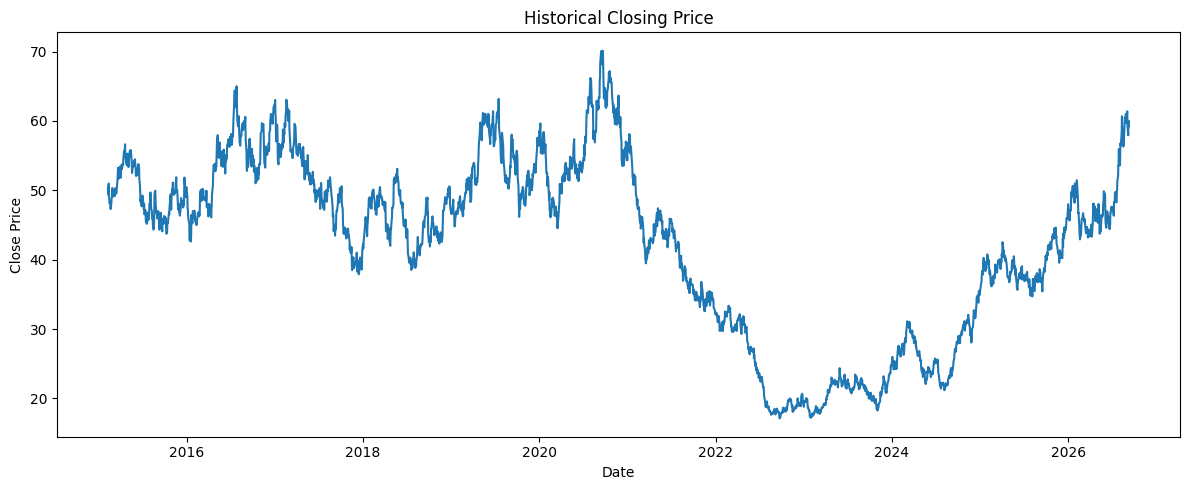

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(raw_df["Date"], raw_df["Close"])
plt.title("Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.tight_layout()
plt.savefig("../results/historical_price.png", dpi=150)
plt.show()


## 2. Preprocess: Scale + Sliding Windows

Steps:
1. Extract the `Close` column.
2. Scale it to `[-1, 1]` with `MinMaxScaler` (helps RNN training converge).
3. Build sliding-window sequences: `lookback=20` days of prices -> predict day 21.
4. Chronological 80/20 train/test split (no shuffling -- order matters for time series).
5. Convert to PyTorch tensors of shape `(batch, seq_len, 1)`.


In [4]:
LOOKBACK = 20
TRAIN_FRAC = 0.8

data = prepare_dataset(DATA_PATH, lookback=LOOKBACK, train_frac=TRAIN_FRAC)

X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
scaler = data["scaler"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: torch.Size([2403, 20, 1])
X_test : torch.Size([601, 20, 1])
y_train: torch.Size([2403])
y_test : torch.Size([601])


## 3. Define the Models

Both models share the same hyperparameters so the comparison is fair:
- `input_dim=1` (single feature: price)
- `hidden_dim=32`
- `num_layers=2`
- `output_dim=1` (predict next day's price)


In [5]:
HIDDEN_DIM = 32
NUM_LAYERS = 2
NUM_EPOCHS = 150
LEARNING_RATE = 0.01

lstm_model = LSTMModel(input_dim=1, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, output_dim=1)
gru_model = GRUModel(input_dim=1, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, output_dim=1)

print(lstm_model)
print(gru_model)


LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## 4. Train Both Models

We train each model with Mean Squared Error loss and the Adam optimizer,
tracking training loss per epoch and total training time.

In [6]:
print("Training LSTM...")
lstm_losses, lstm_time = train_model(lstm_model, X_train, y_train,
                                      num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, print_every=25)
print(f"LSTM training time: {lstm_time:.2f}s")


Training LSTM...


Epoch    1/150 | Training MSE: 0.262715


Epoch   25/150 | Training MSE: 0.009155


Epoch   50/150 | Training MSE: 0.004331


Epoch   75/150 | Training MSE: 0.002617


Epoch  100/150 | Training MSE: 0.002280


Epoch  125/150 | Training MSE: 0.002092


Epoch  150/150 | Training MSE: 0.001924
LSTM training time: 22.31s


In [7]:
print("Training GRU...")
gru_losses, gru_time = train_model(gru_model, X_train, y_train,
                                    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, print_every=25)
print(f"GRU training time: {gru_time:.2f}s")


Training GRU...
Epoch    1/150 | Training MSE: 0.314543


Epoch   25/150 | Training MSE: 0.003930


Epoch   50/150 | Training MSE: 0.001733


Epoch   75/150 | Training MSE: 0.001117


Epoch  100/150 | Training MSE: 0.001052


Epoch  125/150 | Training MSE: 0.001023


Epoch  150/150 | Training MSE: 0.001004
GRU training time: 14.85s


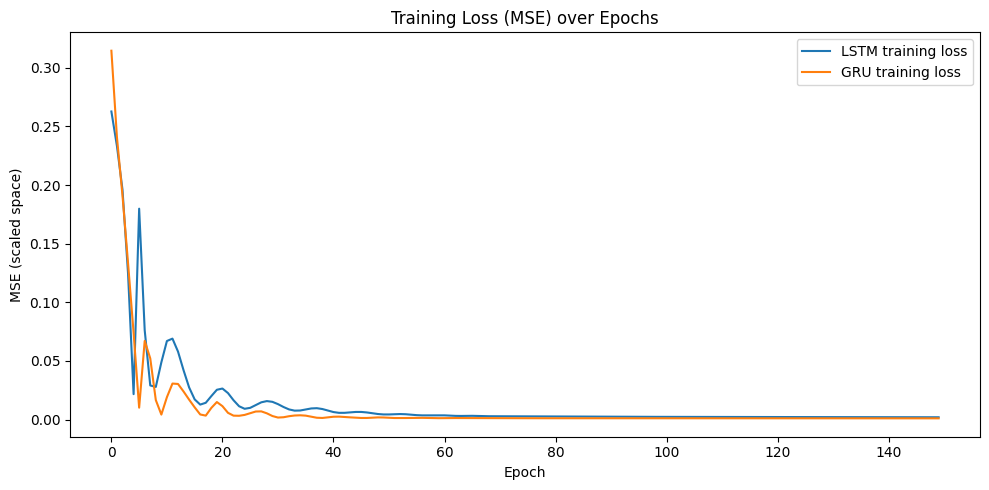

In [8]:
plot_loss_curves(lstm_losses, gru_losses, save_path="../results/loss_curves.png")


## 5. Evaluate on the Test Set

We inverse-transform predictions back to real price units and compute MSE/RMSE
for both models on unseen test data.

In [9]:
lstm_results = evaluate_model(lstm_model, X_test, y_test, scaler)
gru_results = evaluate_model(gru_model, X_test, y_test, scaler)

comparison = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "Test MSE": [lstm_results["mse"], gru_results["mse"]],
    "Test RMSE": [lstm_results["rmse"], gru_results["rmse"]],
    "Training Time (s)": [lstm_time, gru_time],
})
comparison


,Model,Test MSE,Test RMSE,Training Time (s)
0,LSTM,1.065493,1.032227,22.312985
1,GRU,0.593667,0.770498,14.848312


In [10]:
comparison.to_csv("../results/model_comparison.csv", index=False)
comparison


,Model,Test MSE,Test RMSE,Training Time (s)
0,LSTM,1.065493,1.032227,22.312985
1,GRU,0.593667,0.770498,14.848312


## 6. Visualize: Actual vs Predicted Prices

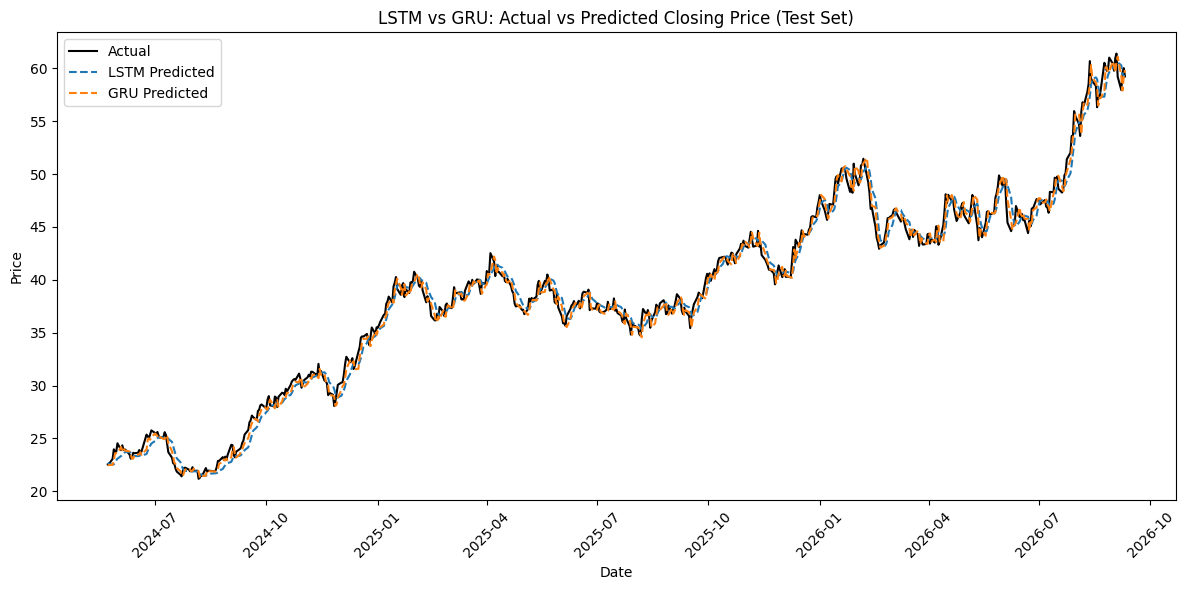

In [11]:
plot_predictions(
    dates=data["test_dates"],
    y_true=lstm_results["y_true"],
    y_pred_lstm=lstm_results["y_pred"],
    y_pred_gru=gru_results["y_pred"],
    title="LSTM vs GRU: Actual vs Predicted Closing Price (Test Set)",
    save_path="../results/predictions_comparison.png",
)


## 6b. Naive Baseline: "Tomorrow ~= Today"

Before trusting the LSTM/GRU results, we compare them against the simplest
possible forecaster: predict that tomorrow's price equals today's price
(a "random walk" / persistence baseline). Because financial time series are
close to a random walk, **this naive baseline is often surprisingly hard to
beat** -- if our RNNs don't clearly outperform it, that's an important, honest
result, not a bug.

In [12]:
naive_pred_scaled = data["X_test"][:, -1, 0].numpy()
naive_pred = inverse_transform(scaler, naive_pred_scaled)
y_true_naive = lstm_results["y_true"]

naive_mse = mean_squared_error(y_true_naive, naive_pred)
naive_rmse = float(np.sqrt(naive_mse))

comparison_with_baseline = pd.concat([
    comparison,
    pd.DataFrame([{
        "Model": "Naive (t+1 = t)",
        "Test MSE": naive_mse,
        "Test RMSE": naive_rmse,
        "Training Time (s)": 0.0,
    }])
], ignore_index=True)

comparison_with_baseline.to_csv("../results/model_comparison.csv", index=False)
comparison_with_baseline


,Model,Test MSE,Test RMSE,Training Time (s)
0,LSTM,1.065493,1.032227,22.312985
1,GRU,0.593667,0.770498,14.848312
2,Naive (t+1 = t),0.552156,0.743072,0.000000


## 6c. Residuals

A residual plot (actual minus predicted) helps spot systematic bias (e.g., the
model consistently lagging behind sharp moves) that a single RMSE number can
hide.

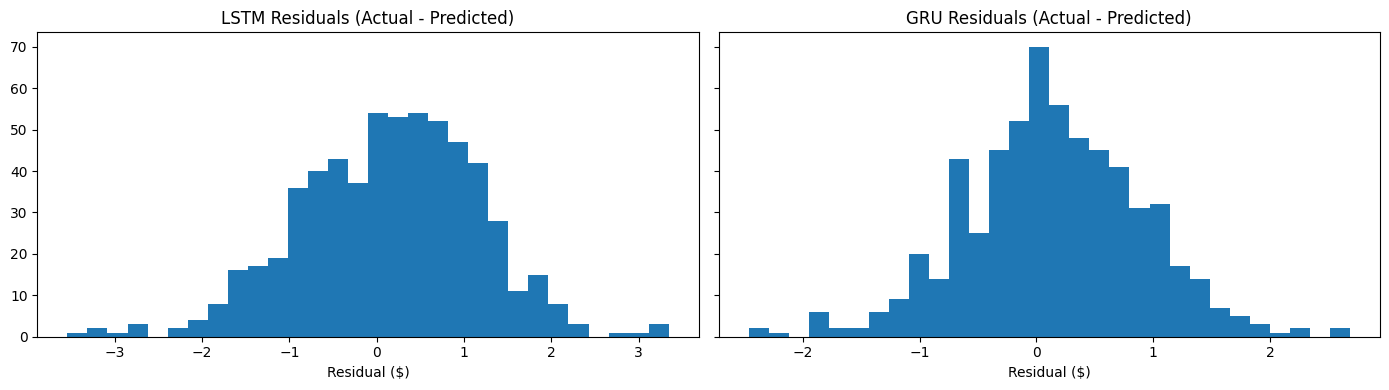

LSTM residual mean: 0.1466, std: 1.0218
GRU  residual mean: 0.1386, std: 0.7579


In [13]:
residuals_lstm = lstm_results["y_true"] - lstm_results["y_pred"]
residuals_gru = gru_results["y_true"] - gru_results["y_pred"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].hist(residuals_lstm, bins=30)
axes[0].set_title("LSTM Residuals (Actual - Predicted)")
axes[0].set_xlabel("Residual ($)")
axes[1].hist(residuals_gru, bins=30)
axes[1].set_title("GRU Residuals (Actual - Predicted)")
axes[1].set_xlabel("Residual ($)")
plt.tight_layout()
plt.savefig("../results/residuals.png", dpi=150)
plt.show()

print(f"LSTM residual mean: {residuals_lstm.mean():.4f}, std: {residuals_lstm.std():.4f}")
print(f"GRU  residual mean: {residuals_gru.mean():.4f}, std: {residuals_gru.std():.4f}")


## 7. Conclusions & Reflection

- **Always check the naive baseline** (Section 6b): if LSTM/GRU don't clearly
  beat "tomorrow = today," that's a meaningful, honest finding about the
  difficulty of the task, not just a modeling shortcoming.
- Both models are trained with identical hyperparameters (hidden size, layers,
  epochs, learning rate) so the MSE/RMSE and training-time comparison above is
  apples-to-apples.
- GRUs have fewer parameters than LSTMs (no separate cell state), so they often
  train a bit faster per epoch -- check the `Training Time (s)` column above to
  see if that held true here.
- **Caveat:** this run uses a synthetic, randomly-generated price series. Swap
  in real market data (see the note at the top) before drawing conclusions
  about actual predictive power.
- **Critical thinking:** stock price prediction from price history alone is a
  notoriously hard problem -- markets are influenced by countless external
  factors that a univariate time series model cannot see. For a grounded
  perspective on the limits of ML hype vs. reality, see *AI Snake Oil* by
  Arvind Narayanan & Sayash Kapoor (https://press.princeton.edu/books/hardcover/9780691249131/ai-snake-oil).

### Possible next steps
- Add more input features (Open/High/Low/Volume, technical indicators).
- Try different lookback windows or add Dropout for regularization.
- Compare against a Transformer-based time series model.
